In [40]:
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
df = pd.read_excel(r"C:\Users\Admin\Desktop\supplier_ranking_grades.xlsx")
df.head()


,supplier,quality,quantity,conditions and method of payment,serviceability and communicativeness of the supplier,reputation of the supplier and its competence,flexibility,financial condition of the supplier,condition of the supplier's assets,business results and number of employees,price,delivery time,supplier's location and traffic connections
0,1,4,350,3,3,4,4,4,3,5,5,2.0,50
1,2,2,350,2,5,4,3,5,4,6,7,3.0,60
2,3,2,450,3,6,5,4,7,8,9,8,4.0,30
3,4,4,260,3,6,8,5,7,8,9,7,1.0,40
4,5,3,170,3,7,6,2,6,5,4,7,2.0,35


In [42]:
df.columns = [
    "supplier",
    "quality",
    "quantity",
    "payment_terms",
    "serviceability",
    "reputation",
    "flexibility",
    "financial_condition",
    "assets_condition",
    "business_results",
    "price",
    "delivery_time",
    "location"
]

In [43]:
print(df.head())

   supplier  quality  quantity  payment_terms  serviceability  reputation  \
0         1        4       350              3               3           4   
1         2        2       350              2               5           4   
2         3        2       450              3               6           5   
3         4        4       260              3               6           8   
4         5        3       170              3               7           6   

   flexibility  financial_condition  assets_condition  business_results  \
0            4                    4                 3                 5   
1            3                    5                 4                 6   
2            4                    7                 8                 9   
3            5                    7                 8                 9   
4            2                    6                 5                 4   

   price  delivery_time  location  
0      5            2.0        50  
1      7      

In [44]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   supplier             35 non-null     int64  
 1   quality              35 non-null     int64  
 2   quantity             35 non-null     int64  
 3   payment_terms        35 non-null     int64  
 4   serviceability       35 non-null     int64  
 5   reputation           35 non-null     int64  
 6   flexibility          35 non-null     int64  
 7   financial_condition  35 non-null     int64  
 8   assets_condition     35 non-null     int64  
 9   business_results     35 non-null     int64  
 10  price                35 non-null     int64  
 11  delivery_time        35 non-null     float64
 12  location             35 non-null     int64  
dtypes: float64(1), int64(12)
memory usage: 3.7 KB
None


In [45]:
print(df.isnull().sum())

supplier               0
quality                0
quantity               0
payment_terms          0
serviceability         0
reputation             0
flexibility            0
financial_condition    0
assets_condition       0
business_results       0
price                  0
delivery_time          0
location               0
dtype: int64


In [46]:
criteria_cols = [
    "quality",
    "payment_terms",
    "serviceability",
    "reputation",
    "flexibility",
    "financial_condition",
    "assets_condition",
    "business_results",
    "price",
    "delivery_time",
    "location"
]
df["average_score"] = df[criteria_cols].mean(axis=1)

In [47]:
df["rank"] = df["average_score"].rank(ascending=False, method="dense")

df_sorted = df.sort_values(by="average_score", ascending=False)

print("Top 10 suppliers:")
print(df_sorted[["supplier", "average_score", "rank"]].head(10))

Top 10 suppliers:
    supplier  average_score  rank
15        16      24.909091   1.0
14        15      17.818182   2.0
8          9      16.272727   3.0
13        14      13.272727   4.0
12        13      12.363636   5.0
28        29      11.909091   6.0
33        34      11.454545   7.0
24        25      11.272727   8.0
7          8      11.000000   9.0
29        30      10.818182  10.0


In [49]:
weights = {
    "quality": 0.20,
    "price": 0.20,
    "delivery_time": 0.20,
    "flexibility": 0.15,
    "financial_condition": 0.10,
    "serviceability": 0.15
}

df["weighted_score"] = (
    df["quality"] * weights["quality"] +
    df["price"] * weights["price"] +
    df["delivery_time"] * weights["delivery_time"] +
    df["flexibility"] * weights["flexibility"] +
    df["financial_condition"] * weights["financial_condition"] +
    df["serviceability"] * weights["serviceability"]
)

df["weighted_rank"] = df["weighted_score"].rank(ascending=False, method="dense")

print(df[["supplier", "weighted_score", "weighted_rank"]].head())

   supplier  weighted_score  weighted_rank
0         1            3.65           21.0
1         2            4.10           16.0
2         3            5.00            2.0
3         4            4.75            5.0
4         5            4.35           11.0


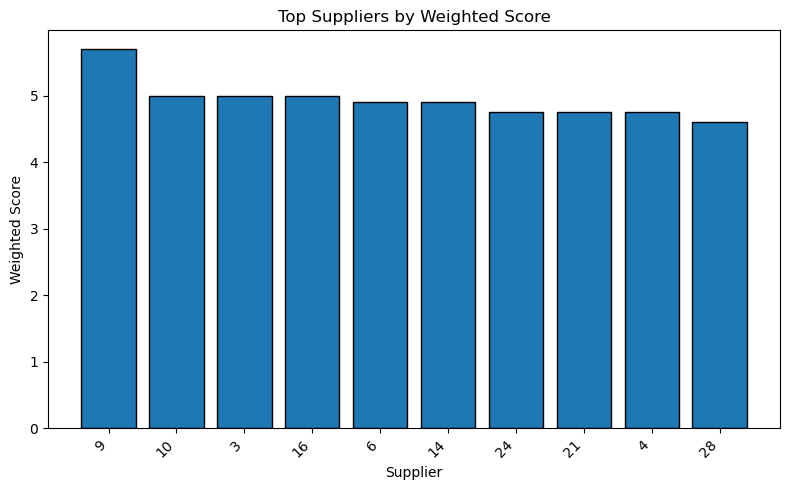

In [51]:
import os
os.makedirs("images", exist_ok=True)
top10 = df.sort_values("weighted_score", ascending=False).head(10)
plt.figure(figsize=(8,5))
plt.bar(top10["supplier"].astype(str), top10["weighted_score"], edgecolor="black")
plt.title("Top Suppliers by Weighted Score")
plt.xlabel("Supplier")
plt.ylabel("Weighted Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("images/top_suppliers_weighted_score.png", dpi=300, bbox_inches="tight")
plt.show()

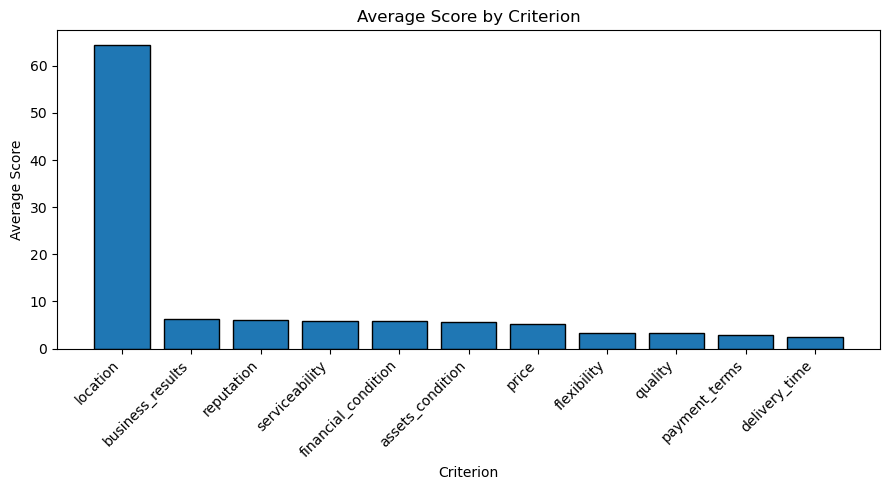

In [53]:
criteria_avg = df[criteria_cols].mean().sort_values(ascending=False)
plt.figure(figsize=(9,5))
plt.bar(criteria_avg.index, criteria_avg.values, edgecolor="black")
plt.title("Average Score by Criterion")
plt.xlabel("Criterion")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("images/average_score_by_criterion.png", dpi=300, bbox_inches="tight")
plt.show()

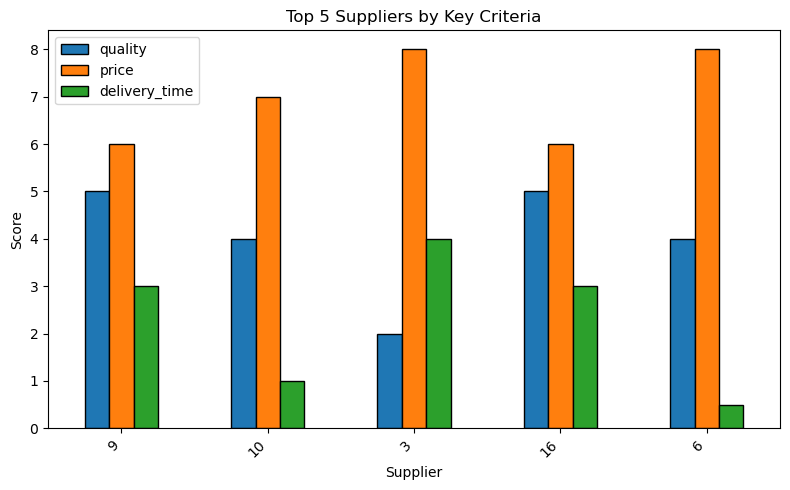

In [54]:
top5 = df.sort_values("weighted_score", ascending=False).head(5)
top5_plot = top5.set_index("supplier")[["quality", "price", "delivery_time"]]
top5_plot.plot(kind="bar", figsize=(8,5), edgecolor="black")
plt.title("Top 5 Suppliers by Key Criteria")
plt.xlabel("Supplier")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("images/top5_suppliers_key_criteria.png", dpi=300, bbox_inches="tight")
plt.show()